# Week 01 - Transform Basics

3D 좌표계, 회전행렬, 이동벡터, 4x4 transformation matrix를 실습하는 노트북.

## Day 1: 3D 점 하나 변환하기
* 목표
    * R, t가 3D 점을 어떻게 바꾸는지 가장 작은 예제로 확인합니다.

* 할 일
    * P_o = [1, 0, 0] 정의
    * z축 90도 회전행렬 Rz 정의
    * translation t 정의
    * P_c = R P_o + t 계산
    * 4x4 matrix T로 같은 결과 확인

1. 3D point

`P_o = np.array([1, 0, 0])`

* P_o = object frame 기준의 point
* object frame 기준으로 x축 방향 1만큼 떨어진 점으로,
* 이 점은 물체 자기 좌표계에서 오른쪽으로 1만큼 떨어진 점이다.

2. xyz 축?
* 보통 기하/선형대수에서 많이 쓰는 3D 좌표계는 오른손 좌표계, right-handed coordinate system이다.

x축: 오른쪽
y축: 위쪽
z축: 내 쪽, 화면 밖으로 나오는 방향

        y
        ↑
        |
        |
        O --------→ x
       /
      /
     z, 화면 밖 / 내 쪽

이라고 생각하면 된다.

오른손으로 생각하면:

엄지  = +x
검지  = +y
중지  = +z

로 잡을 수 있다. 이때 x × y = z이다.

여기서 x × y = z의 ×는 일반 곱셈이 아니라 cross product, 외적이다.
x축 방향 벡터와 y축 방향 벡터를 외적하면 z축 방향 벡터가 나온다.
는 뜻입니다.

보통 단위벡터로 쓰면:

x축 단위벡터 i = [1, 0, 0]
y축 단위벡터 j = [0, 1, 0]
z축 단위벡터 k = [0, 0, 1]

그리고 오른손 좌표계에서는:

i × j = k

입니다.

왜냐하면 외적은 두 벡터에 모두 수직인 방향을 만들기 때문입니다. x축과 y축은 둘 다 xy 평면 위에 있죠. 이 둘에 동시에 수직인 방향은 +z 또는 -z 둘 중 하나입니다.

그중 어느 방향을 +z로 정할지는 오른손 법칙으로 정합니다.

오른손 손가락을 x축에서 y축 방향으로 감으면
엄지가 가리키는 방향이 +z

그래서:

x × y = z
y × z = x
z × x = y

가 됩니다.

반대로 순서를 바꾸면 방향이 반대가 됩니다.

y × x = -z
z × y = -x
x × z = -y

이게 중요한 이유는 회전 방향 때문입니다. 예를 들어 z축 기준 +90도 회전을 말할 때, “+z 방향에서 내려다봤을 때 x축이 y축으로 가는 방향”을 양의 회전으로 잡습니다. 그래서 Day 1에서:

P_o = [1, 0, 0]

을 z축 기준 +90도 회전하면:

[0, 1, 0]

이 되는 것입니다.

6D pose에서 이걸 왜 신경 쓰냐면, 좌표계를 오른손/왼손으로 헷갈리거나 축 방향을 반대로 잡으면 회전행렬 R은 숫자로는 그럴듯해 보여도 물체 pose가 뒤집혀 보일 수 있습니다. Week 1에서 좌표계와 4×4 transformation matrix를 먼저 잡는 이유도 여기에 있습니다.


다만 카메라 좌표계에서는 convention이 달라질 수 있다.
OpenCV camera frame에서는 보통:

x: 이미지 오른쪽
y: 이미지 아래쪽
z: 카메라 앞쪽, 장면 안쪽

으로 많이 쓴다.
나중에 PnP로 가면 “OpenCV camera frame convention”을 따로 정리해야 한다.

3. Rotation matrix R

* z축 90도 회전

```python
    theta = np.deg2rad(90)

    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])
```
* R_z: R은 Rotation matirix, z는 z-axis 기준 회전

z축 기준 회전행렬이 왜 이렇게 생겼나요?

“z축을 기준으로 회전하니까 x, y 성분만 서로 섞이고, z 성분은 그대로 남는다”고 이해하면 된다.

z축 회전은 xy 평면에서 일어납니다.

2D에서 점 [x, y]를 각도 theta만큼 회전하면:

x' = cos(theta) * x - sin(theta) * y
y' = sin(theta) * x + cos(theta) * y

입니다.

3D에서는 여기에 z를 그대로 붙입니다.

x' = cos(theta) * x - sin(theta) * y
y' = sin(theta) * x + cos(theta) * y
z' = z

그래서 행렬이 이렇게 됩니다.

[ x' ]   [ cosθ  -sinθ   0 ] [ x ]
[ y' ] = [ sinθ   cosθ   0 ] [ y ]
[ z' ]   [  0      0     1 ] [ z ]

즉, 이 행렬은 이렇게 읽으면 됩니다.

x, y는 회전 때문에 섞인다.
z축 기준으로 돌렸으므로 z값은 변하지 않는다.

실제로 P_o = [1, 0, 0], theta = 90도를 넣으면:

cos(90°) = 0
sin(90°) = 1

이므로,

Rz =
[ 0  -1   0 ]
[ 1   0   0 ]
[ 0   0   1 ]

이고,

Rz @ [1, 0, 0] = [0, 1, 0]

이 됩니다.

* [1, 0, 0]을 z축 기준으로 90도 돌리면 [0, 1, 0]이 된다.

즉, [1, 0, 0]  →  [0, 1, 0]

object frame에서 x축 방향에 있던 점
→ 회전 후 camera frame에서는 y축 방향으로 보인다.

직관적으로는 xy 평면 위에서 회전한다고 보면 된다. z축은 위에서 내려다보는 “회전축”이고, 점은 xy 평면에서 돌아간다.

회전 전:

        y
        ↑
        |
        |
        O --------→ x
                  P = [1, 0, 0]


z축 기준 +90도 회전 후:

        y
        ↑
        P = [0, 1, 0]
        |
        O --------→ x

주의할 점은 이 예시는 active rotation, 즉 “점을 실제로 돌린다”고 생각한 경우이다. 좌표계 자체를 돌려서 같은 점을 새 좌표로 표현하는 경우에는 부호나 방향이 반대로 보일 수 있다. 지금 노트북에서는 일단:

P_c = R @ P_o + t

처럼 object frame의 점을 camera frame으로 변환한다는 관점으로 보면 된다.


4. Translation vector t
t = np.array([1, 2, 3])

이건 “회전한 점을 camera frame에서 x로 1, y로 2, z로 3만큼 옮긴다”는 뜻입니다.

P_c = Rz @ P_o + t

NumPy에서 @는 matrix multiplication이며, np.matmul의 shorthand입니다. 오늘은 Rz @ P_o처럼 행렬과 벡터를 곱할 때 쓰시면 됩니다.

예상 결과는:

Rz @ [1, 0, 0] = [0, 1, 0]
[0, 1, 0] + [1, 2, 3] = [1, 3, 3]

4. Homogeneous transformation matrix T

R과 t를 따로 쓰면:

P_c = R @ P_o + t

4×4 matrix로 묶으면:

T = np.eye(4)
T[:3, :3] = Rz
T[:3, 3] = t

P_o_h = np.array([1, 0, 0, 1])
P_c_h = T @ P_o_h

3×3 회전행렬 R과 3D 이동벡터 t를 하나의 4×4 행렬 T 안에 합쳐서, 회전과 이동을 한 번의 행렬곱으로 처리하려는 것입니다.

원래 방식은 이거였습니다.

P_c = Rz @ P_o + t

즉,

먼저 회전하고
그다음 이동한다.

입니다.

그런데 이것은 행렬곱 하나로는 안 됩니다. 왜냐하면 + t가 따로 붙어 있기 때문입니다.

그래서 3D point [x, y, z]를 4D처럼 보이게 확장합니다.

P_o = [1, 0, 0]
P_o_h = [1, 0, 0, 1]

마지막에 붙은 1은 실제 공간 차원이 하나 늘었다는 뜻이 아닙니다. 이것은 homogeneous coordinate, 동차좌표입니다.

쉽게 말하면:

translation까지 행렬곱 안에 넣기 위해 붙이는 계산용 1

입니다.

T = np.eye(4)는 뭔가요?
T = np.eye(4)

는 4×4 identity matrix를 만듭니다.

T =
[1  0  0  0]
[0  1  0  0]
[0  0  1  0]
[0  0  0  1]

이 상태는 “아무 회전도, 아무 이동도 하지 않는 변환”입니다.

이제 여기에 Rz와 t를 채워 넣습니다.


여기서 결과 P_c_h[:3]도 [1, 3, 3]이 나와야 합니다.

이게 나중에 6D pose에서 보게 될 형태입니다.

T_co =
[ R  t ]
[ 0  1 ]

읽는 법은:

object frame의 점을 camera frame의 점으로 바꾸는 변환이다.

8. T[:3, :3] = Rz는 뭔가요?
T[:3, :3] = Rz

는 4×4 행렬의 왼쪽 위 3×3 부분에 Rz를 넣는다는 뜻입니다.

즉,

T =
[ R의 1행        ? ]
[ R의 2행        ? ]
[ R의 3행        ? ]
[ 0  0  0        1 ]

구체적으로는:

T =
[ R00  R01  R02  0 ]
[ R10  R11  R12  0 ]
[ R20  R21  R22  0 ]
[  0    0    0   1 ]

여기서 왼쪽 위 R 부분은 회전을 담당합니다.

9. T[:3, 3] = t는 뭔가요?
T[:3, 3] = t

는 마지막 column의 위쪽 3개 칸에 translation vector t를 넣는다는 뜻입니다.

예를 들어:

t = [1, 2, 3]

이면,

T =
[ R00  R01  R02  1 ]
[ R10  R11  R12  2 ]
[ R20  R21  R22  3 ]
[  0    0    0   1 ]

이 됩니다.

즉, T는 이렇게 생긴 행렬입니다.

T =
[ R  t ]
[ 0  1 ]

조금 더 풀면:

T =
[ R00  R01  R02  tx ]
[ R10  R11  R12  ty ]
[ R20  R21  R22  tz ]
[  0    0    0   1 ]

10. 왜 T @ P_o_h를 하면 R @ P + t가 되나요?

P_o_h = [x, y, z, 1]이라고 해보겠습니다.

그러면:

[ R00  R01  R02  tx ] [ x ]
[ R10  R11  R12  ty ] [ y ]
[ R20  R21  R22  tz ] [ z ]
[  0    0    0   1  ] [ 1 ]

결과는:

x' = R00*x + R01*y + R02*z + tx*1
y' = R10*x + R11*y + R12*z + ty*1
z' = R20*x + R21*y + R22*z + tz*1
w' = 1

즉,

P_c = R @ P_o + t

와 똑같아집니다.

그래서:

P_c = Rz @ P_o + t

와

P_c_h = T @ P_o_h

는 같은 결과를 내야 합니다.

Week 1 Day 1에서도 바로 이 두 방식, 즉 R P + t와 T P_h가 같은지 확인하는 것이 산출물입니다.

11. 숫자로 직접 보면
P_o = [1, 0, 0]
Rz @ P_o = [0, 1, 0]
t = [1, 2, 3]

이면:

P_c = [0, 1, 0] + [1, 2, 3]
    = [1, 3, 3]

4×4 행렬로 쓰면:

T =
[ 0  -1   0   1 ]
[ 1   0   0   2 ]
[ 0   0   1   3 ]
[ 0   0   0   1 ]

그리고:

P_o_h = [1, 0, 0, 1]

계산하면:

P_c_h =
[ 0*1 + (-1)*0 + 0*0 + 1*1 ]
[ 1*1 +   0*0  + 0*0 + 2*1 ]
[ 0*1 +   0*0  + 1*0 + 3*1 ]
[ 0*1 +   0*0  + 0*0 + 1*1 ]

= [1, 3, 3, 1]

마지막 1을 빼고 앞의 3개만 보면:

P_c_h[:3] = [1, 3, 3]

입니다.

12. SciPy Rotation은 뭘 해주는 건가요?

수님이 긁어온 SciPy 문서의 핵심은 이것입니다.

3D 회전은 여러 방식으로 표현할 수 있는데, SciPy Rotation 클래스는 그 표현들 사이를 바꿔주고, 벡터에 회전을 적용하고, 회전끼리 합성하거나 역변환할 수 있게 해주는 도구입니다.

SciPy 공식 문서에서도 Rotation은 3D rotation을 다루는 클래스이고, quaternion, rotation matrix, rotation vector, Euler angle 등으로 초기화하거나 표현할 수 있다고 설명합니다. 또한 vector에 rotation을 apply하거나, rotation composition, inversion도 지원합니다.

지금 당장 수님이 알아야 할 건 이 정도입니다.

from scipy.spatial.transform import Rotation as R

여기서 R은 우리가 쓰는 rotation matrix의 R과 이름이 겹치지만, 의미가 조금 다릅니다.

from scipy.spatial.transform import Rotation as R

의 R은 SciPy Rotation 클래스의 별칭입니다.

반면에:

Rz = np.array([...])

의 Rz는 실제 3×3 rotation matrix입니다.

예를 들어 SciPy로 z축 90도 회전을 만들면:

from scipy.spatial.transform import Rotation as R

rot = R.from_euler('z', 90, degrees=True)
Rz = rot.as_matrix()

이렇게 됩니다.

즉,

R.from_euler('z', 90, degrees=True)

는 “z축 기준 90도 회전”이라는 회전 객체를 만들고,

.as_matrix()

는 그 회전을 3×3 rotation matrix로 꺼내는 것입니다.

SciPy 문서 예시에서도 z축 90도 회전은 rotation matrix, quaternion, rotation vector, Euler angle 등으로 서로 변환될 수 있음을 보여줍니다.


13. “object frame의 점을 camera frame의 점으로 바꾼다”는 뜻

이 문장이 제일 중요합니다.

object frame의 점을 camera frame의 점으로 바꾸는 변환이다.

예를 들어 물체 위의 한 점이 있습니다.

P_o = [1, 0, 0]

이건 물체 자신 기준입니다.

즉:

물체 중심에서 봤을 때, 이 점은 x축 방향으로 1만큼 떨어져 있다.

그런데 카메라는 그 물체를 다른 위치와 방향에서 보고 있습니다. 그래서 카메라 입장에서는 같은 점의 좌표가 다르게 보입니다.

P_c = [1, 3, 3]

이건 카메라 기준입니다.

즉:

카메라에서 봤을 때, 그 점은 x로 1, y로 3, z로 3 위치에 있다.

이때 필요한 것이 바로:

P_c = R_co @ P_o + t_co

입니다.

여기서 표기법을 조심해야 합니다.

T_co

를 수업/논문/코드마다 다르게 읽는 경우가 있지만, 이 공부방에서는 일단 이렇게 정합시켜두면 좋습니다.

T_co: object frame 좌표를 camera frame 좌표로 바꾸는 transform

즉:

P_c = T_co @ P_o_h

입니다.

말로 하면:

object frame에서 표현된 점 P_o를, camera frame에서 표현된 점 P_c로 바꾼다.

네, 수님이 말한 것처럼 회전행렬과 transform matrix를 통해 camera coordinate로 변환시키는 것이 맞습니다.

이게 6D pose estimation과 직접 연결됩니다. 프로젝트 목표 자체도 RGB-D나 샘플 데이터를 이용해 물체 하나의 6D pose를 추정하는 것이고, 6D pose는 translation 3D와 rotation 3D, 즉 t + R로 표현됩니다.

In [1]:
import numpy as np

# 1. Object frame에서의 3D point
P_o = np.array([1.0, 0.0, 0.0])

# 2. z축 기준 90도 회전
theta = np.deg2rad(90)

Rz = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta),  np.cos(theta), 0.0],
    [0.0,            0.0,           1.0]
])

# 3. Translation vector
t = np.array([1.0, 2.0, 3.0])

# 4. R @ P + t 방식
P_c = Rz @ P_o + t

print("P_o:", P_o)
print("Rz @ P_o:", Rz @ P_o)
print("t:", t)
print("P_c = Rz @ P_o + t:", P_c)

# 5. 4x4 Homogeneous transformation matrix 방식
T_co = np.eye(4)
T_co[:3, :3] = Rz
T_co[:3, 3] = t

P_o_h = np.array([P_o[0], P_o[1], P_o[2], 1.0])
P_c_h = T_co @ P_o_h

print("\nT_co:\n", T_co)
print("P_o_h:", P_o_h)
print("P_c_h = T_co @ P_o_h:", P_c_h)
print("P_c_h[:3]:", P_c_h[:3])

# 6. 두 방식이 같은지 확인
print("\nSame result?", np.allclose(P_c, P_c_h[:3]))

P_o: [1. 0. 0.]
Rz @ P_o: [6.123234e-17 1.000000e+00 0.000000e+00]
t: [1. 2. 3.]
P_c = Rz @ P_o + t: [1. 3. 3.]

T_co:
 [[ 6.123234e-17 -1.000000e+00  0.000000e+00  1.000000e+00]
 [ 1.000000e+00  6.123234e-17  0.000000e+00  2.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  3.000000e+00]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]
P_o_h: [1. 0. 0. 1.]
P_c_h = T_co @ P_o_h: [1. 3. 3. 1.]
P_c_h[:3]: [1. 3. 3.]

Same result? True


통과 기준은 다음이다.

1. P_o와 P_c의 frame 차이를 설명할 수 있다.
2. R은 회전, t는 이동이라는 것을 설명할 수 있다.
3. P_c = R @ P_o + t의 의미를 설명할 수 있다.
4. t와 T를 구분할 수 있다.
5. 4x4 transformation matrix가 왜 필요한지 대략 설명할 수 있다.

오늘 더 하면 좋은 것은 개념 공부가 아니라 정리이다.

오늘 남길 산출물
1. 노트북 Day 1 코드 실행
2. P_c = [1, 3, 3] 결과 확인
3. 위 최종 수정본을 markdown 셀에 붙여넣기
4. glossary.md에 아래 세 용어 추가
   - Rotation Matrix
   - Translation Vector
   - Homogeneous Transformation

## Day 2: 여러 개의 3D 점 변환하기
* 목표

    * 점 하나가 아니라 여러 점을 한 번에 변환합니다.

* 할 일
    * 큐브 또는 삼각형의 3D 점 여러 개 정의
    * R과 t를 한 번에 적용
    * 변환 전 좌표와 변환 후 좌표 비교

# Week 01 Day 2: 여러 개의 3D 점 변환하기

## 오늘 목표

Day 1에서는 3D 점 하나만 변환했다.

```python
P_o = [1, 0, 0]
P_c = R @ P_o + t
```

Day 2에서는 점 하나가 아니라 여러 개의 3D point를 한 번에 변환한다.

6D pose 관점에서는 물체가 점 하나로 이루어진 것이 아니라, 여러 개의 3D point로 이루어진다.

```text
물체 위의 여러 3D 점들
        ↓
같은 R, t 적용
        ↓
camera frame 기준 point set
```

즉, 오늘 핵심 문장은 이것이다.

```text
6D pose에서는 물체 위의 모든 3D 점이 같은 R, t로 함께 움직인다.
```

---

## 1. 여러 개의 3D point 정의

삼각형 모양의 object point 3개를 만든다.

```python
import numpy as np

# object frame 기준 3D point 3개
points_o = np.array([
    [0.0, 0.0, 0.0],   # 점 A: object origin
    [1.0, 0.0, 0.0],   # 점 B: x축 방향
    [0.0, 1.0, 0.0]    # 점 C: y축 방향
])

print(points_o)
print(points_o.shape)
```

예상 shape는 다음이다.

```text
(3, 3)
```

의미는 다음이다.

```text
점 개수 = 3개
각 점의 좌표 성분 = x, y, z 3개
```

즉, `points_o`는 다음 구조이다.

```text
[
  [x1, y1, z1],
  [x2, y2, z2],
  [x3, y3, z3]
]
```

---

## 2. z축 기준 90도 회전행렬 정의

Day 1과 같은 `Rz`를 쓴다.

```python
theta = np.deg2rad(90)

Rz = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta),  np.cos(theta), 0.0],
    [0.0,            0.0,           1.0]
])

print(Rz)
```

이 회전은 다음 의미이다.

```text
z축 기준으로 +90도 회전한다.
x축 방향 점은 y축 방향으로 간다.
y축 방향 점은 -x축 방향으로 간다.
z값은 그대로 유지된다.
```

---

## 3. translation vector 정의

```python
t = np.array([1.0, 2.0, 3.0])

print(t)
```

의미는 다음이다.

```text
회전된 모든 점을 x 방향 1, y 방향 2, z 방향 3만큼 이동시킨다.
```

---

## 4. 여러 점에 R과 t를 적용하기

여기서 제일 중요한 코드이다.

```python
points_c = points_o @ Rz.T + t

print(points_c)
```

왜 `Rz.T`를 쓰는지 중요하다.

Day 1에서는 점 하나를 column vector처럼 보고 이렇게 했다.

```python
P_c = Rz @ P_o + t
```

하지만 Day 2에서는 여러 점을 row vector 형태로 저장했다.

```python
points_o =
[
  [x1, y1, z1],
  [x2, y2, z2],
  [x3, y3, z3]
]
```

이런 형태에서는 각 row가 하나의 point이다.

따라서 NumPy에서 여러 row point에 같은 rotation을 적용하려면 보통 이렇게 쓴다.

```python
points_c = points_o @ Rz.T + t
```

핵심은 다음이다.

```text
점 하나 column vector 방식:
P_c = R @ P_o + t

여러 점 row vector 방식:
points_c = points_o @ R.T + t
```

왜냐면 점 하나일 때는 바로 벡터 연산이라서 그렇게 표현하는게 맞다.
---

## 5. 손으로 예상해보기

원래 점은 다음이다.

```text
A = [0, 0, 0]
B = [1, 0, 0]
C = [0, 1, 0]
```

z축 기준 +90도 회전하면 다음이 된다.

```text
A_rot = [0, 0, 0]
B_rot = [0, 1, 0]
C_rot = [-1, 0, 0]
```

여기에 `t = [1, 2, 3]`을 더하면 다음이다.

```text
A_c = [0, 0, 0] + [1, 2, 3] = [1, 2, 3]
B_c = [0, 1, 0] + [1, 2, 3] = [1, 3, 3]
C_c = [-1, 0, 0] + [1, 2, 3] = [0, 2, 3]
```

따라서 예상 결과는 다음이다.

```text
[
  [1, 2, 3],
  [1, 3, 3],
  [0, 2, 3]
]
```

---

## 6. 변환 전후 비교표 만들기

```python
for i, (p_o, p_c) in enumerate(zip(points_o, points_c)):
    print(f"Point {i}")
    print("  object frame:", p_o)
    print("  camera frame:", p_c)
```

해석은 다음이다.

```text
같은 실제 점이라도 object frame에서 본 좌표와 camera frame에서 본 좌표는 다르다.
그 차이를 만드는 것이 R과 t이다.
```
일단 기본 회전행렬 3개를 알아두면 된다.

Rx = x축 기준 회전
Ry = y축 기준 회전
Rz = z축 기준 회전
1. x축 기준 회전 Rx

x축 기준 회전은 x축은 그대로 두고, y와 z가 섞인다.

Rx =
[ 1     0       0    ]
[ 0   cosθ   -sinθ  ]
[ 0   sinθ    cosθ  ]

의미는 다음이다.

x축을 회전축으로 잡는다.
따라서 x값은 그대로이다.
회전 때문에 y값과 z값이 서로 섞인다.

예를 들어 x축 기준 +90도 회전이면 다음이다.

[0, 1, 0] -> [0, 0, 1]

즉, y축 방향 점이 z축 방향으로 간다.

2. y축 기준 회전 Ry

y축 기준 회전은 y축은 그대로 두고, x와 z가 섞인다.

Ry =
[  cosθ   0   sinθ ]
[   0     1    0   ]
[ -sinθ   0   cosθ ]

의미는 다음이다.

y축을 회전축으로 잡는다.
따라서 y값은 그대로이다.
회전 때문에 x값과 z값이 서로 섞인다.

예를 들어 y축 기준 +90도 회전이면 다음이다.

[0, 0, 1] -> [1, 0, 0]

즉, z축 방향 점이 x축 방향으로 간다.

또는 다음도 성립한다.

[1, 0, 0] -> [0, 0, -1]
3. z축 기준 회전 Rz

z축 기준 회전은 z축은 그대로 두고, x와 y가 섞인다.

Rz =
[ cosθ   -sinθ   0 ]
[ sinθ    cosθ   0 ]
[  0       0     1 ]

의미는 다음이다.

z축을 회전축으로 잡는다.
따라서 z값은 그대로이다.
회전 때문에 x값과 y값이 서로 섞인다.

예를 들어 z축 기준 +90도 회전이면 다음이다.

[1, 0, 0] -> [0, 1, 0]

즉, x축 방향 점이 y축 방향으로 간다.

회전행렬을 외우는 패턴

외우는 방식은 이것이다.

어느 축 기준으로 회전하는가?
그 축 성분은 그대로 남는다.
나머지 두 축 성분이 cos, sin으로 섞인다.

예를 들어:

x축 기준 회전:
x는 그대로
y, z가 섞인다

y축 기준 회전:
y는 그대로
x, z가 섞인다

z축 기준 회전:
z는 그대로
x, y가 섞인다

## 8. 오늘 반드시 이해할 것

오늘은 이 3개만 이해하면 된다.

```text
1. 여러 3D point는 shape이 보통 (N, 3)이다.
2. 모든 point에 같은 R과 t를 적용하면 물체 전체가 같이 움직인다.
3. row vector 형태의 point array에서는 points @ R.T + t를 쓴다.
```

---

## 9. 6D pose와 연결

6D pose estimation에서 물체는 점 하나가 아니다.

물체의 CAD model, point cloud, corner point, keypoint는 모두 여러 개의 3D point로 표현된다.

```text
object model points
[
  [x1, y1, z1],
  [x2, y2, z2],
  ...
  [xN, yN, zN]
]
```

pose `R, t`가 주어지면 이 모든 점은 같은 방식으로 camera frame으로 변환된다.

```python
points_c = points_o @ R.T + t
```

이게 나중에 다음 곳에 그대로 쓰인다.

```text
PnP:
object frame의 3D keypoints를 camera/image로 보냄

ICP:
source point cloud 전체를 target point cloud에 맞게 변환함

Visualization:
object 좌표축이나 cube corner를 camera/image 위에 그림
```


In [ ]:
import numpy as np

# 1. object frame 기준 3D point 여러 개 정의
points_o = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0]
])

# 2. z축 기준 90도 회전행렬 정의
theta = np.deg2rad(90)

Rz = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta),  np.cos(theta), 0.0],
    [0.0,            0.0,           1.0]
])

# 3. translation vector 정의
t = np.array([1.0, 2.0, 3.0])

# 4. 여러 point에 같은 R, t 적용
points_c = points_o @ Rz.T + t

# 5. 결과 출력
print("points_o shape:", points_o.shape)
print("Rz shape:", Rz.shape)
print("t shape:", t.shape)
print("points_c shape:", points_c.shape)

print("\nObject frame points:")
print(points_o)

print("\nCamera frame points:")
print(points_c)

# 6. 변환 전후 비교
print("\nBefore / After:")
for i, (p_o, p_c) in enumerate(zip(points_o, points_c)):
    print(f"Point {i}: {p_o} -> {p_c}")

In [ ]:
import numpy as np

theta = np.deg2rad(90)

Rx = np.array([
    [1.0, 0.0,            0.0],
    [0.0, np.cos(theta), -np.sin(theta)],
    [0.0, np.sin(theta),  np.cos(theta)]
])

Ry = np.array([
    [ np.cos(theta), 0.0, np.sin(theta)],
    [ 0.0,           1.0, 0.0],
    [-np.sin(theta), 0.0, np.cos(theta)]
])

Rz = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta),  np.cos(theta), 0.0],
    [0.0,            0.0,           1.0]
])

ex = np.array([1.0, 0.0, 0.0])
ey = np.array([0.0, 1.0, 0.0])
ez = np.array([0.0, 0.0, 1.0])

print("Rx @ ex:", Rx @ ex)
print("Rx @ ey:", Rx @ ey)
print("Rx @ ez:", Rx @ ez)

print("\nRy @ ex:", Ry @ ex)
print("Ry @ ey:", Ry @ ey)
print("Ry @ ez:", Ry @ ez)

print("\nRz @ ex:", Rz @ ex)
print("Rz @ ey:", Rz @ ey)
print("Rz @ ez:", Rz @ ez)

## Day 3: Homogeneous Transformation Matrix 이해하기
* 목표

    * R과 t를 4x4 matrix T로 묶는 이유를 이해합니다.

* 할 일
    * 3x3 R과 3x1 t를 4x4 T로 만들기
    * 3D point를 homogeneous coordinate [x, y, z, 1]로 바꾸기
    * T @ P_h 계산
    * R @ P + t 결과와 비교

## 오늘 목표

Day 1에서는 점 하나를 이렇게 변환했다.

```python
P_c = R @ P_o + t
```

Day 2에서는 여러 점을 이렇게 변환했다.

```python
points_c = points_o @ R.T + t
```

Day 3에서는 `R`과 `t`를 따로 쓰지 않고, 하나의 4x4 matrix `T`로 묶는다.

핵심 문장은 이것이다.

```text
T는 rotation과 translation을 한 번에 적용하기 위해 만든 4x4 pose matrix이다.
```

---

## 1. 왜 4x4 matrix가 필요한가

기존 방식은 다음이다.

```python
P_c = R @ P_o + t
```

이 식은 두 단계로 되어 있다.

```text
1. R @ P_o 로 회전한다.
2. + t 로 이동한다.
```

즉, rotation은 행렬곱이고 translation은 덧셈이다.

그런데 pose를 다룰 때는 회전과 이동을 하나의 연산으로 묶고 싶다.

그래서 3D point `[x, y, z]` 뒤에 계산용 `1`을 붙인다.

```python
P_o   = [x, y, z]
P_o_h = [x, y, z, 1]
```

이것을 homogeneous coordinate, 동차좌표라고 한다.

---

## 2. `T`의 구조

4x4 transformation matrix는 다음 구조이다.

```text
T =
[ R  t ]
[ 0  1 ]
```

더 자세히 쓰면 다음이다.

```text
T =
[ R00  R01  R02  tx ]
[ R10  R11  R12  ty ]
[ R20  R21  R22  tz ]
[  0    0    0    1 ]
```

여기서 의미는 다음이다.

```text
왼쪽 위 3x3 = rotation matrix R
마지막 column 위쪽 3개 = translation vector t
마지막 row = homogeneous coordinate 계산을 위한 고정 row
```

---

## 3. 오늘 쓸 예제

Day 1과 같은 예제를 쓴다.

```python
import numpy as np

P_o = np.array([1.0, 0.0, 0.0])

theta = np.deg2rad(90)

Rz = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta),  np.cos(theta), 0.0],
    [0.0,            0.0,           1.0]
])

t = np.array([1.0, 2.0, 3.0])
```

의미는 다음이다.

```text
P_o = object frame 기준 3D point
Rz = z축 기준 +90도 회전행렬
t = [1, 2, 3] translation vector
```

---

## 4. 먼저 Day 1 방식으로 계산하기

```python
P_c_direct = Rz @ P_o + t

print(P_c_direct)
```

예상 결과는 다음이다.

```text
[1. 3. 3.]
```

계산 순서는 다음이다.

```text
P_o = [1, 0, 0]
Rz @ P_o = [0, 1, 0]
[0, 1, 0] + [1, 2, 3] = [1, 3, 3]
```

---

## 5. 4x4 transformation matrix 만들기

```python
T_co = np.eye(4)

T_co[:3, :3] = Rz
T_co[:3, 3] = t

print(T_co)
```

예상 구조는 다음이다.

```text
T_co =
[ 0  -1   0   1 ]
[ 1   0   0   2 ]
[ 0   0   1   3 ]
[ 0   0   0   1 ]
```

실제 NumPy에서는 `6.123234e-17` 같은 값이 보일 수 있다. 이것은 사실상 0이다.

---

## 6. 코드 한 줄씩 해석하기

### `T_co = np.eye(4)`

```python
T_co = np.eye(4)
```

4x4 identity matrix를 만든다.

```text
[1  0  0  0]
[0  1  0  0]
[0  0  1  0]
[0  0  0  1]
```

이 상태는 아무 회전도, 아무 이동도 하지 않는 기본 transform이다.

---

### `T_co[:3, :3] = Rz`

```python
T_co[:3, :3] = Rz
```

왼쪽 위 3x3 영역에 rotation matrix를 넣는다.

```text
[ R00  R01  R02  0 ]
[ R10  R11  R12  0 ]
[ R20  R21  R22  0 ]
[  0    0    0   1 ]
```

이 부분이 회전을 담당한다.

---

### `T_co[:3, 3] = t`

```python
T_co[:3, 3] = t
```

마지막 column의 위쪽 3개 칸에 translation vector를 넣는다.

```text
[ R00  R01  R02  tx ]
[ R10  R11  R12  ty ]
[ R20  R21  R22  tz ]
[  0    0    0    1 ]
```

이 부분이 이동을 담당한다.

---

## 7. 3D point를 homogeneous coordinate로 바꾸기

원래 점은 다음이다.

```python
P_o = np.array([1.0, 0.0, 0.0])
```

homogeneous coordinate는 뒤에 `1`을 붙인다.

```python
P_o_h = np.array([1.0, 0.0, 0.0, 1.0])
```

중요한 점은 이것이다.

```text
P_o_h는 4D 공간의 새로운 점이 아니다.
3D point에 translation 계산용 1을 붙인 표현이다.
```

즉,

```text
P_o   = [x, y, z]
P_o_h = [x, y, z, 1]
```

이다.

---

## 8. `T_co @ P_o_h` 계산하기

```python
P_c_h = T_co @ P_o_h

print(P_c_h)
print(P_c_h[:3])
```

예상 결과는 다음이다.

```text
P_c_h     = [1. 3. 3. 1.]
P_c_h[:3] = [1. 3. 3.]
```

여기서 `P_c_h[:3]`만 실제 3D point이다.

마지막 `1`은 homogeneous coordinate의 계산용 값이다.

---

## 9. 왜 `T @ P_h`가 `R @ P + t`와 같은가

`P_o_h = [x, y, z, 1]`이라고 하자.

```text
T =
[ R00  R01  R02  tx ]
[ R10  R11  R12  ty ]
[ R20  R21  R22  tz ]
[  0    0    0    1 ]
```

그러면 `T @ P_o_h`는 다음이다.

```text
x' = R00*x + R01*y + R02*z + tx*1
y' = R10*x + R11*y + R12*z + ty*1
z' = R20*x + R21*y + R22*z + tz*1
w' = 1
```

앞의 세 줄만 보면 다음과 같다.

```text
[x', y', z'] = R @ [x, y, z] + t
```

즉, 다음 두 계산은 같은 결과를 낸다.

```python
P_c_direct = Rz @ P_o + t
P_c_h = T_co @ P_o_h
```

---

## 10. 두 방식이 같은지 확인하기

```python
print("P_c_direct:", P_c_direct)
print("P_c_h[:3]:", P_c_h[:3])
print("same result:", np.allclose(P_c_direct, P_c_h[:3]))
```

예상 결과는 다음이다.

```text
P_c_direct: [1. 3. 3.]
P_c_h[:3]: [1. 3. 3.]
same result: True
```

`np.allclose`를 쓰는 이유는 floating point error 때문이다.

예를 들어 이론적으로 0이어야 하는 값이 코드에서는 `6.123234e-17`처럼 아주 작게 나올 수 있다.


1. T_co 이름 뜻

T_co는 보통 다음처럼 읽는다.

T_co = transform from object frame to camera frame

In [1]:
import numpy as np

# 1. object frame 기준 3D point
P_o = np.array([1.0, 0.0, 0.0])

# 2. z축 기준 +90도 rotation matrix
theta = np.deg2rad(90)

Rz = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta),  np.cos(theta), 0.0],
    [0.0,            0.0,           1.0]
])

# 3. translation vector
t = np.array([1.0, 2.0, 3.0])

# 4. 기존 방식: R @ P + t
P_c_direct = Rz @ P_o + t

# 5. 4x4 transformation matrix 만들기
T_co = np.eye(4)
T_co[:3, :3] = Rz
T_co[:3, 3] = t

# 6. 3D point를 homogeneous coordinate로 변환
P_o_h = np.array([P_o[0], P_o[1], P_o[2], 1.0])

# 7. T @ P_h 방식
P_c_h = T_co @ P_o_h

# 8. 결과 출력
print("P_o:", P_o)
print("Rz:\n", Rz)
print("t:", t)

print("\nP_c_direct = Rz @ P_o + t:")
print(P_c_direct)

print("\nT_co:")
print(T_co)

print("\nP_o_h:")
print(P_o_h)

print("\nP_c_h = T_co @ P_o_h:")
print(P_c_h)

print("\nP_c_h[:3]:")
print(P_c_h[:3])

print("\nSame result?")
print(np.allclose(P_c_direct, P_c_h[:3]))

P_o: [1. 0. 0.]
Rz:
 [[ 6.123234e-17 -1.000000e+00  0.000000e+00]
 [ 1.000000e+00  6.123234e-17  0.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00]]
t: [1. 2. 3.]

P_c_direct = Rz @ P_o + t:
[1. 3. 3.]

T_co:
[[ 6.123234e-17 -1.000000e+00  0.000000e+00  1.000000e+00]
 [ 1.000000e+00  6.123234e-17  0.000000e+00  2.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  3.000000e+00]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

P_o_h:
[1. 0. 0. 1.]

P_c_h = T_co @ P_o_h:
[1. 3. 3. 1.]

P_c_h[:3]:
[1. 3. 3.]

Same result?
True


## Day 4: 좌표계 방향 구분하기
* 목표

    * T_co와 T_oc가 다르다는 것을 이해합니다.

* 할 일
    * T_co 정의
    * T_oc = inverse(T_co) 계산
    * object point -> camera point 변환
    * camera point -> object point로 다시 복원
    * 복원 결과가 원래 P_o와 같은지 확인

## 오늘 목표

Day 3에서는 `R`과 `t`를 4x4 transformation matrix `T`로 묶었다.

Day 4에서는 변환 방향을 구분한다.

핵심 문장은 이것이다.

```text
T_co와 T_oc는 서로 반대 방향의 transform이다.
```

이 공부방에서는 다음 convention을 쓴다.

```text
T_co = object frame의 좌표를 camera frame의 좌표로 바꾸는 transform
T_oc = camera frame의 좌표를 object frame의 좌표로 바꾸는 transform
```

즉,

```text
P_c = T_co @ P_o_h
P_o = T_oc @ P_c_h
```

이다.

---

## 1. 왜 방향이 중요한가

같은 점이라도 어떤 frame 기준으로 보느냐에 따라 좌표값이 달라진다.

```text
P_o = object frame 기준 point
P_c = camera frame 기준 point
```

`T_co`는 object 기준 좌표를 camera 기준 좌표로 바꾼다.

```text
object frame point
        ↓ T_co
camera frame point
```

반대로 `T_oc`는 camera 기준 좌표를 object 기준 좌표로 되돌린다.

```text
camera frame point
        ↓ T_oc
object frame point
```

따라서 `T_co`와 `T_oc`는 같은 matrix가 아니다.

```text
T_oc = inverse(T_co)
```

---

## 2. 직관

예를 들어 물체 위의 한 점이 있다.

```python
P_o = [1, 0, 0]
```

이것은 object frame 기준이다.

`T_co`를 적용하면 camera frame 기준 좌표가 된다.

```python
P_c_h = T_co @ P_o_h
```

그 결과가 예를 들어 다음이라고 하자.

```text
P_c = [1, 3, 3]
```

이제 이 camera frame 좌표를 다시 object frame으로 되돌리려면 `T_oc`를 써야 한다.

```python
P_o_recovered_h = T_oc @ P_c_h
```

결과는 원래 점과 같아야 한다.

```text
P_o_recovered = [1, 0, 0]
```

## 4. 예상 결과

핵심 결과는 다음이다.

```text
P_o_h = [1, 0, 0, 1]

P_c_h = [1, 3, 3, 1]

P_o_recovered_h = [1, 0, 0, 1]

np.allclose(P_o_h, P_o_recovered_h) = True
```

실제 출력에서는 `6.123234e-17` 같은 작은 값이 나올 수 있다.

이 값은 사실상 0이다.

---

## 5. `np.linalg.inv(T_co)`의 의미

```python
T_oc = np.linalg.inv(T_co)
```

이 코드는 `T_co`의 inverse matrix, 역행렬을 구한다.

즉, `T_co`가 하던 일을 반대로 하는 matrix를 만든다.

```text
T_co: object -> camera
T_oc: camera -> object
```

그래서 다음이 성립한다.

```text
T_oc @ T_co = I
T_co @ T_oc = I
```

여기서 `I`는 identity matrix, 단위행렬이다.

즉, 갔다가 다시 돌아오면 원래대로 돌아와야 한다.

```text
P_o_h
  -> T_co 적용
P_c_h
  -> T_oc 적용
P_o_recovered_h
```

---

## 6. inverse transform의 구조

지금은 `np.linalg.inv`를 쓰면 된다.

하지만 개념적으로는 이런 구조이다.

```text
T_co =
[ R  t ]
[ 0  1 ]
```

이때 inverse는 다음 형태이다.

```text
T_oc =
[ R.T   -R.T @ t ]
[  0        1    ]
```

즉, inverse transform은 단순히 `t`에 마이너스만 붙이는 것이 아니다.

중요한 점은 이것이다.

```text
회전도 되돌려야 하고,
이동도 되돌려야 한다.
```

그래서 translation inverse 부분이 그냥 `-t`가 아니라 다음이 된다.

```text
-R.T @ t
```

한가지 다시 언급하자면,
대문자는 행렬, 소문자는 벡터 표현이다.

그러므로 Transform matrix와 translation vector를 혼동하지 말자.

Day 4에서는 이 공식을 완벽히 외울 필요는 없다.

일단은 다음만 이해하면 된다.

```text
T_oc = np.linalg.inv(T_co)
```

---

## 7. 자주 하는 실수

### 실수 1. `T_co`와 `T_oc`를 같은 것으로 생각한다

틀리다.

```text
T_co: object -> camera
T_oc: camera -> object
```

둘은 반대 방향이다.

---

### 실수 2. `P_o`에 `T_oc`를 곱한다

보통 틀린 방향이다.

```text
P_o는 object frame 기준이다.
T_oc는 camera -> object 변환이다.
```

따라서 `T_oc @ P_o_h`는 의미가 맞지 않는다.

Day 4에서는 다음 방향을 기억한다.

```text
P_c_h = T_co @ P_o_h
P_o_h = T_oc @ P_c_h
```

---

### 실수 3. inverse translation을 그냥 `-t`라고 생각한다

회전이 없는 경우에는 `-t`처럼 보일 수 있다.

하지만 회전이 있으면 inverse translation은 보통 다음이다.

```text
-R.T @ t
```

---

## 8. 6D pose pipeline에서 왜 중요한가

6D pose estimation에서는 모델이나 알고리즘이 `object-to-camera pose`를 추정하는 경우가 많다.

즉, 결과가 보통 이런 형태일 수 있다.

```text
T_co = object frame을 camera frame으로 보내는 pose
```

이걸 이미지 위에 projection하거나, point cloud를 camera frame으로 옮길 때 사용한다.

하지만 어떤 상황에서는 반대 방향도 필요하다.

```text
camera frame의 point를 object frame으로 보고 싶을 때
object local coordinate로 되돌리고 싶을 때
ROS TF에서 parent-child 방향을 확인할 때
ICP 결과 transform 방향을 해석할 때
```

이때 inverse transform이 필요하다.

따라서 Day 4의 핵심은 이것이다.

```text
pose matrix는 방향이 있다.
방향을 헷갈리면 숫자는 맞아도 결과가 틀려 보인다.
```
## 8. `T_oc`는 어떻게 만들어지는가

코드에서는 이렇게 만든다.

```python
T_oc = np.linalg.inv(T_co)
```

의미는 다음이다.

```text
T_co가 object → camera 변환이면,
그 역행렬 T_oc는 camera → object 변환이다.
```

즉,

```text
T_oc = T_co^{-1}
```

이다.

그리고 다음이 성립한다.

```text
T_oc @ T_co = I
T_co @ T_oc = I
```

여기서 `I`는 단위행렬이다.


In [4]:
import numpy as np

# 1. object frame 기준 3D point
P_o = np.array([1.0, 0.0, 0.0])

# 2. homogeneous coordinate로 확장
P_o_h = np.array([P_o[0], P_o[1], P_o[2], 1.0])

# 3. z축 기준 +90도 rotation matrix
theta = np.deg2rad(90)

Rz = np.array([
    [np.cos(theta), -np.sin(theta), 0.0],
    [np.sin(theta),  np.cos(theta), 0.0],
    [0.0,            0.0,           1.0]
])

# 4. translation vector
t = np.array([1.0, 2.0, 3.0])

# 5. object -> camera transform
T_co = np.eye(4)
T_co[:3, :3] = Rz
T_co[:3, 3] = t

# 6. camera -> object transform
T_oc = np.linalg.inv(T_co)

# 7. object frame point를 camera frame point로 변환
P_c_h = T_co @ P_o_h

# 8. camera frame point를 다시 object frame point로 복원
P_o_recovered_h = T_oc @ P_c_h

print("P_o_h:")
print(P_o_h)

print("\nT_co:")
print(T_co)

print("\nP_c_h = T_co @ P_o_h:")
print(P_c_h)

print("\nT_oc = inverse(T_co):")
print(T_oc)

print("\nP_o_recovered_h = T_oc @ P_c_h:")
print(P_o_recovered_h)

print("\nP_o_h and P_o_recovered_h are same?")
print(np.allclose(P_o_h, P_o_recovered_h))

P_o_h:
[1. 0. 0. 1.]

T_co:
[[ 6.123234e-17 -1.000000e+00  0.000000e+00  1.000000e+00]
 [ 1.000000e+00  6.123234e-17  0.000000e+00  2.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  3.000000e+00]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

P_c_h = T_co @ P_o_h:
[1. 3. 3. 1.]

T_oc = inverse(T_co):
[[ 6.123234e-17  1.000000e+00  0.000000e+00 -2.000000e+00]
 [-1.000000e+00  6.123234e-17 -0.000000e+00  1.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00 -3.000000e+00]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

P_o_recovered_h = T_oc @ P_c_h:
[1. 0. 0. 1.]

P_o_h and P_o_recovered_h are same?
True


## Day 5: Object Frame, Camera Frame, World Frame 정리하기
* 목표

    * 각 좌표계가 무엇을 의미하는지 말로 설명할 수 있게 만듭니다.

* 할 일
    * object frame 정의
    * camera frame 정의
    * world frame 정의
    * 각 frame에서 같은 점의 좌표가 어떻게 달라지는지 예시 작성

## 0. 오늘의 목표

오늘은 새로운 알고리즘을 배우는 날이 아니다.

오늘의 목표는 다음 세 가지이다.

1. object frame, camera frame, world frame의 차이를 말로 설명할 수 있다.
2. 같은 3D 점도 어떤 frame에서 보느냐에 따라 좌표값이 달라진다는 것을 이해한다.
3. `T_co`, `T_oc`, `T_wo`, `T_wc` 같은 표기법을 보고 입력 frame과 출력 frame을 구분할 수 있다.

6D pose estimation에서 이 개념은 매우 중요하다.

6D pose estimation은 결국 물체가 카메라 기준으로 어디에 있고 어떤 방향을 보고 있는지 찾는 문제이다.

즉, 대부분의 경우 우리가 찾고 싶은 것은 다음 변환이다.

```text
T_co: object frame -> camera frame
```

다시 말해, object frame에 정의된 3D point들을 camera frame에서 표현할 수 있게 해주는 `R`, `t`, `T`를 찾는 것이 6D pose estimation의 핵심이다.

## 1. Frame이란 무엇인가?

frame은 3D 공간에서 좌표를 재기 위한 기준이다.

하나의 frame은 보통 다음 요소를 가진다.

```text
1. 원점 origin
2. x축 방향
3. y축 방향
4. z축 방향
```

중요한 점은 3D point 자체가 바뀌지 않아도, 어떤 frame에서 보느냐에 따라 좌표값은 달라질 수 있다는 것이다.

예를 들어, 책상 위에 컵이 하나 있다고 하자.

컵 자체는 같은 위치에 있지만,

```text
컵 중심을 기준으로 보면: [0, 0, 0]
카메라 기준으로 보면: [0.2, 0.1, 0.8]
로봇 base 기준으로 보면: [0.5, -0.3, 0.7]
```

처럼 좌표값이 달라진다.

즉, 좌표는 point의 절대적인 성질이 아니라, 어떤 frame을 기준으로 표현했는지에 따라 달라지는 값이다.

## 2. Object Frame

object frame은 물체 자체에 붙어 있는 좌표계이다.

예를 들어 큐브 물체가 있다면, object frame의 원점은 보통 다음 중 하나로 잡을 수 있다.

```text
1. 물체의 중심
2. 물체의 한쪽 코너
3. CAD model에서 정해진 기준점
```

object frame의 특징은 다음과 같다.

```text
- 물체와 함께 움직인다.
- 물체가 회전하면 object frame도 같이 회전한다.
- 물체 표면의 3D point들은 object frame 기준으로 고정된 좌표를 가진다.
```

예를 들어 큐브의 한 꼭짓점이 object frame에서 다음과 같다고 하자.

```text
P_o = [0.05, 0.05, 0.05]
```

이 말은 다음 뜻이다.

```text
이 점은 물체 기준으로 x 방향 5cm, y 방향 5cm, z 방향 5cm 위치에 있다.
```

여기서 중요한 점은 물체가 카메라 앞에서 어디로 이동하거나 회전해도, object frame 기준 좌표 `P_o`는 변하지 않는다는 것이다.

변하는 것은 camera frame에서 본 좌표 `P_c`이다.

## 3. Camera Frame

camera frame은 카메라를 기준으로 하는 좌표계이다.

컴퓨터비전에서 자주 쓰는 camera frame convention은 보통 다음과 같다.

```text
x축: 이미지 오른쪽 방향
y축: 이미지 아래쪽 방향
z축: 카메라 앞쪽 방향
```

즉, 카메라 앞에 있는 물체는 보통 `z > 0` 값을 가진다.

예를 들어 어떤 물체 중심이 camera frame에서 다음과 같다고 하자.

```text
t = [0.2, 0.1, 0.8]
```

이 말은 다음 뜻이다.

```text
물체 origin이 카메라 기준으로
오른쪽 0.2m,
아래쪽 0.1m,
앞쪽 0.8m
위치에 있다.
```

6D pose estimation에서 `tvec` 또는 translation vector가 보통 이런 의미를 가진다.

특히 OpenCV `solvePnP`에서 나오는 `rvec`, `tvec`는 보통 object point를 camera frame으로 보내는 pose를 의미한다.

즉, 개념적으로 다음과 같다.

```text
P_c = R_co @ P_o + t_co
```

여기서

```text
P_o: object frame 기준 3D point
P_c: camera frame 기준 3D point
R_co: object frame에서 camera frame으로 가는 rotation
t_co: object frame origin이 camera frame에서 어디에 있는지 나타내는 translation
```

## 4. World Frame

world frame은 장면 전체를 설명하기 위한 고정된 기준 좌표계이다.

예를 들어 다음과 같은 기준을 world frame으로 잡을 수 있다.

```text
- 실험실 바닥 기준 좌표계
- 로봇 base frame
- calibration board 기준 좌표계
- 첫 번째 카메라 위치 기준 좌표계
```

world frame은 object나 camera처럼 움직이는 대상에 붙어 있다기보다, 전체 장면을 통일해서 설명하기 위한 기준으로 쓰인다.

예를 들어 로봇 작업 공간에서는 다음처럼 여러 frame이 연결된다.

```text
world frame
-> robot base frame
-> camera frame
-> object frame
```

6D pose mini project 초반에는 world frame을 너무 깊게 다루지 않아도 된다.

지금 가장 중요한 것은 다음이다.

```text
object frame의 점을 camera frame으로 변환할 수 있어야 한다.
```

즉, 지금은 `T_co`를 가장 우선적으로 이해하면 된다.

## 5. 같은 점, 다른 좌표

하나의 실제 3D point가 있다고 하자.

이 점은 물리적으로 하나의 점이다.

하지만 frame이 달라지면 좌표 표현이 달라진다.

예를 들어 object frame에서 다음 점이 있다.

```text
P_o = [1, 0, 0]
```

이 점은 object frame 기준으로 x축 방향으로 1만큼 떨어진 점이다.

그런데 object frame이 camera frame 기준으로 회전하고 이동해 있다면, 같은 점은 camera frame에서 다르게 보인다.

```text
P_c = R_co @ P_o + t_co
```

예를 들어,

```text
R_co = z축 기준 90도 회전
t_co = [1, 2, 3]
P_o = [1, 0, 0]
```

이면,

```text
R_co @ P_o = [0, 1, 0]
P_c = [0, 1, 0] + [1, 2, 3]
P_c = [1, 3, 3]
```

즉, 같은 점이지만

```text
object frame 기준 좌표: [1, 0, 0]
camera frame 기준 좌표: [1, 3, 3]
```

가 된다.

핵심은 다음이다.

```text
좌표값이 바뀐 것이지, 실제 점이 다른 점이 된 것은 아니다.
```

## 6. 표기법: T_co 읽는 법

여기서는 다음 convention을 사용한다.

```text
T_ab = b frame에 있는 point를 a frame으로 변환하는 matrix
```

즉,

```text
P_a = T_ab @ P_b
```

이다.

따라서 `T_co`는 다음 뜻이다.

```text
T_co = object frame의 point를 camera frame으로 변환하는 matrix
```

수식으로 쓰면 다음과 같다.

```text
P_c = T_co @ P_o
```

homogeneous coordinate를 쓰면 더 정확히는 다음이다.

```text
P_c_h = T_co @ P_o_h
```

여기서 `_h`는 homogeneous coordinate라는 뜻이다.

예를 들어,

```text
P_o_h = [x_o, y_o, z_o, 1]
P_c_h = [x_c, y_c, z_c, 1]
```

이다.

## 7. 자주 나오는 변환 표기 정리

| 표기 | 의미 | 수식 |
|---|---|---|
| `T_co` | object frame -> camera frame | `P_c = T_co @ P_o` |
| `T_oc` | camera frame -> object frame | `P_o = T_oc @ P_c` |
| `T_wc` | camera frame -> world frame | `P_w = T_wc @ P_c` |
| `T_cw` | world frame -> camera frame | `P_c = T_cw @ P_w` |
| `T_wo` | object frame -> world frame | `P_w = T_wo @ P_o` |
| `T_ow` | world frame -> object frame | `P_o = T_ow @ P_w` |

이 표에서 가장 중요한 것은 아래 규칙이다.

```text
T_ab는 b에서 a로 간다.
```

즉,

```text
T_co는 o에서 c로 간다.
T_oc는 c에서 o로 간다.
```

헷갈리면 항상 다음 문장으로 확인한다.

```text
P_출력 = T_출력입력 @ P_입력
```

예를 들어,

```text
P_c = T_co @ P_o
```

이므로 `T_co`는 object point를 camera point로 바꾸는 변환이다.

## 8. Transform Chain

여러 frame을 거쳐 변환할 수도 있다.

예를 들어 object frame의 점 `P_o`를 world frame으로 보내고 싶다고 하자.

만약 다음 두 변환을 알고 있다면,

```text
T_co: object -> camera
T_wc: camera -> world
```

object point를 world point로 바꾸는 과정은 다음과 같다.

```text
P_c = T_co @ P_o
P_w = T_wc @ P_c
```

따라서 한 번에 쓰면 다음과 같다.

```text
P_w = T_wc @ T_co @ P_o
```

즉,

```text
T_wo = T_wc @ T_co
```

이다.

여기서 순서가 매우 중요하다.

```text
T_wo = T_wc @ T_co
```

이지,

```text
T_wo = T_co @ T_wc
```

가 아니다.

행렬 곱셈에서는 오른쪽 변환이 먼저 적용된다.

```text
P_w = T_wc @ T_co @ P_o
```

를 읽으면,

```text
1. P_o에 T_co를 먼저 적용해서 camera frame으로 보낸다.
2. 그 결과에 T_wc를 적용해서 world frame으로 보낸다.
```

이다.

In [1]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)


# ============================================================
# Week 1 Day 5
# Object Frame, Camera Frame, World Frame 코드 실습
# ============================================================


# ------------------------------------------------------------
# 1. 기본 함수 정의
# ------------------------------------------------------------

def make_T(R, t):
    """
    R: (3, 3) rotation matrix
    t: (3,) translation vector

    return:
        T: (4, 4) homogeneous transformation matrix
    """
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T


def to_homogeneous(P):
    """
    P: (3,) 3D point

    return:
        P_h: (4,) homogeneous point
    """
    return np.append(P, 1.0)


def from_homogeneous(P_h):
    """
    P_h: (4,) homogeneous point

    return:
        P: (3,) 3D point
    """
    return P_h[:3] / P_h[3]


def rotz(theta_deg):
    """
    z-axis rotation matrix
    """
    theta = np.deg2rad(theta_deg)

    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])

    return R


def transform_point(T, P):
    """
    T: (4, 4)
    P: (3,)

    return:
        transformed 3D point
    """
    P_h = to_homogeneous(P)
    P_new_h = T @ P_h
    return from_homogeneous(P_new_h)


# ------------------------------------------------------------
# 2. Object frame 기준 3D point 정의
# ------------------------------------------------------------

# object frame에서 정의된 점
# 물체 기준으로 x 방향 1만큼 떨어진 점
P_o = np.array([1.0, 0.0, 0.0])

print("P_o: object frame 기준 point")
print(P_o)


# ------------------------------------------------------------
# 3. T_co 정의
# ------------------------------------------------------------
# convention:
# T_ab = b frame의 point를 a frame으로 변환하는 matrix
#
# 따라서:
# T_co = object frame -> camera frame
#
# P_c = T_co @ P_o
# ------------------------------------------------------------

R_co = rotz(90)
t_co = np.array([1.0, 2.0, 3.0])
T_co = make_T(R_co, t_co)

print("\nR_co:")
print(R_co)

print("\nt_co:")
print(t_co)

print("\nT_co: object frame -> camera frame")
print(T_co)


# ------------------------------------------------------------
# 4. object point를 camera frame으로 변환
# ------------------------------------------------------------

P_c = transform_point(T_co, P_o)

print("\nP_o: object frame 기준 좌표")
print(P_o)

print("\nP_c: camera frame 기준 좌표")
print(P_c)


# ------------------------------------------------------------
# 5. 같은 3D point가 frame에 따라 다르게 표현됨
# ------------------------------------------------------------

print("\n같은 실제 3D point")
print("--------------------------------")
print(f"object frame에서 표현: {P_o}")
print(f"camera frame에서 표현: {P_c}")


# ------------------------------------------------------------
# 6. inverse transform 확인
# ------------------------------------------------------------
# T_oc = camera frame -> object frame
#
# P_o = T_oc @ P_c
# ------------------------------------------------------------

T_oc = np.linalg.inv(T_co)
P_o_recovered = transform_point(T_oc, P_c)

print("\nT_oc: camera frame -> object frame")
print(T_oc)

print("\nP_o 원래 값:")
print(P_o)

print("\nP_o 복원 값:")
print(P_o_recovered)

print("\n복원 성공 여부:")
print(np.allclose(P_o, P_o_recovered))


# ------------------------------------------------------------
# 7. World frame 추가
# ------------------------------------------------------------
# T_wc = camera frame -> world frame
#
# P_w = T_wc @ P_c
# ------------------------------------------------------------

R_wc = rotz(-90)
t_wc = np.array([10.0, 0.0, 0.0])
T_wc = make_T(R_wc, t_wc)

print("\nT_wc: camera frame -> world frame")
print(T_wc)


# ------------------------------------------------------------
# 8. object -> camera -> world 변환
# ------------------------------------------------------------

P_w_step = transform_point(T_wc, P_c)

print("\nP_o: object frame")
print(P_o)

print("\nP_c = T_co @ P_o: camera frame")
print(P_c)

print("\nP_w = T_wc @ P_c: world frame")
print(P_w_step)


# ------------------------------------------------------------
# 9. Transform chain 확인
# ------------------------------------------------------------
# P_w = T_wc @ T_co @ P_o
#
# 따라서:
# T_wo = T_wc @ T_co
#
# 주의:
# 오른쪽 변환이 먼저 적용된다.
# ------------------------------------------------------------

T_wo = T_wc @ T_co
P_w_direct = transform_point(T_wo, P_o)

print("\nT_wo = T_wc @ T_co")
print(T_wo)

print("\nP_w_step: object -> camera -> world")
print(P_w_step)

print("\nP_w_direct: object -> world")
print(P_w_direct)

print("\n두 결과가 같은가?")
print(np.allclose(P_w_step, P_w_direct))


# ------------------------------------------------------------
# 10. 일부러 틀린 순서로 곱해보기
# ------------------------------------------------------------
# 아래는 틀린 예시다.
#
# T_wrong = T_co @ T_wc
#
# 의미상 frame 연결이 맞지 않는다.
# 행렬 크기는 맞아서 계산은 되지만,
# frame 의미가 깨진다.
# ------------------------------------------------------------

T_wrong = T_co @ T_wc
P_wrong = transform_point(T_wrong, P_o)

print("\n잘못된 chain: T_wrong = T_co @ T_wc")
print(T_wrong)

print("\n잘못된 결과:")
print(P_wrong)

print("\n올바른 결과:")
print(P_w_direct)


# ------------------------------------------------------------
# 11. 여러 개의 object point를 camera/world frame으로 변환
# ------------------------------------------------------------

points_o = np.array([
    [0.0, 0.0, 0.0],   # object origin
    [1.0, 0.0, 0.0],   # object x-axis point
    [0.0, 1.0, 0.0],   # object y-axis point
    [0.0, 0.0, 1.0],   # object z-axis point
])

points_c = []
points_w = []

for P in points_o:
    P_c_i = transform_point(T_co, P)
    P_w_i = transform_point(T_wo, P)

    points_c.append(P_c_i)
    points_w.append(P_w_i)

points_c = np.array(points_c)
points_w = np.array(points_w)

print("\npoints_o: object frame")
print(points_o)

print("\npoints_c: camera frame")
print(points_c)

print("\npoints_w: world frame")
print(points_w)


# ------------------------------------------------------------
# 12. 표처럼 보기
# ------------------------------------------------------------

print("\n각 point의 frame별 좌표")
print("--------------------------------")

for i in range(len(points_o)):
    print(f"Point {i}")
    print(f"  object frame: {points_o[i]}")
    print(f"  camera frame: {points_c[i]}")
    print(f"  world frame : {points_w[i]}")
    print()


# ------------------------------------------------------------
# 13. Day 5 핵심 확인
# ------------------------------------------------------------

print("Day 5 핵심")
print("--------------------------------")
print("1. 같은 3D point도 frame이 다르면 좌표값이 달라진다.")
print("2. T_co는 object frame의 point를 camera frame으로 변환한다.")
print("3. T_wc는 camera frame의 point를 world frame으로 변환한다.")
print("4. T_wo = T_wc @ T_co 이다.")
print("5. 행렬 곱에서는 오른쪽 변환이 먼저 적용된다.")

P_o: object frame 기준 point
[1. 0. 0.]

R_co:
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

t_co:
[1. 2. 3.]

T_co: object frame -> camera frame
[[ 0. -1.  0.  1.]
 [ 1.  0.  0.  2.]
 [ 0.  0.  1.  3.]
 [ 0.  0.  0.  1.]]

P_o: object frame 기준 좌표
[1. 0. 0.]

P_c: camera frame 기준 좌표
[1. 3. 3.]

같은 실제 3D point
--------------------------------
object frame에서 표현: [1. 0. 0.]
camera frame에서 표현: [1. 3. 3.]

T_oc: camera frame -> object frame
[[ 0.  1.  0. -2.]
 [-1.  0. -0.  1.]
 [ 0.  0.  1. -3.]
 [ 0.  0.  0.  1.]]

P_o 원래 값:
[1. 0. 0.]

P_o 복원 값:
[1. 0. 0.]

복원 성공 여부:
True

T_wc: camera frame -> world frame
[[ 0.  1.  0. 10.]
 [-1.  0.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]

P_o: object frame
[1. 0. 0.]

P_c = T_co @ P_o: camera frame
[1. 3. 3.]

P_w = T_wc @ P_c: world frame
[13. -1.  3.]

T_wo = T_wc @ T_co
[[ 1.  0.  0. 12.]
 [ 0.  1.  0. -1.]
 [ 0.  0.  1.  3.]
 [ 0.  0.  0.  1.]]

P_w_step: object -> camera -> world
[13. -1.  3.]

P_w_direct: object -> world
[13. -1.  3.]

두 

## Day 6: 3D 시각화하기
* 목표

    * 변환 전후 점과 좌표축을 눈으로 확인합니다.

* 할 일
    * matplotlib 3D plot 사용
    * object frame의 점 시각화
    * camera frame으로 변환된 점 시각화
    * 좌표축 x, y, z를 함께 표시

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# ============================================================
# Week 1 Day 6
# 3D 변환 시각화하기
# ============================================================

# ------------------------------------------------------------
# 1. 기본 함수 정의
# ------------------------------------------------------------

def make_T(R, t):
    """
    R: (3, 3) rotation matrix
    t: (3,) translation vector
    return: (4, 4) homogeneous transformation matrix
    """
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T


def rotz(theta_deg):
    """
    z-axis rotation matrix
    """
    theta = np.deg2rad(theta_deg)

    R = np.array([
        [np.cos(theta), -np.sin(theta), 0.0],
        [np.sin(theta),  np.cos(theta), 0.0],
        [0.0,            0.0,           1.0],
    ])

    return R


def transform_points(T, points):
    """
    T: (4, 4)
    points: (N, 3)

    return:
        transformed points: (N, 3)
    """
    ones = np.ones((points.shape[0], 1))
    points_h = np.hstack([points, ones])      # (N, 4)
    points_new_h = (T @ points_h.T).T         # (N, 4)
    return points_new_h[:, :3]


def draw_frame(ax, origin, R, name, axis_length=0.5):
    """
    3D 좌표축을 그리는 함수

    origin: frame origin, shape (3,)
    R: frame orientation, shape (3, 3)
       R의 column들이 x, y, z축 방향이라고 생각하면 된다.
    name: frame 이름
    """

    x_axis = R[:, 0] * axis_length
    y_axis = R[:, 1] * axis_length
    z_axis = R[:, 2] * axis_length

    ax.quiver(# 화살표 그리는 함수
        origin[0], origin[1], origin[2], # origin 위치에서 시작해서
        x_axis[0], x_axis[1], x_axis[2], # x_axis 방향으로 향하는 화살표를 그린다.
        linewidth=2
    )
    ax.text(*(origin + x_axis), f"{name}_x") # `ax.text`는 3D plot 위에 라벨다는 함수

    ax.quiver(
        origin[0], origin[1], origin[2],
        y_axis[0], y_axis[1], y_axis[2],
        linewidth=2
    )
    ax.text(*(origin + y_axis), f"{name}_y")

    ax.quiver(
        origin[0], origin[1], origin[2],
        z_axis[0], z_axis[1], z_axis[2],
        linewidth=2
    )
    ax.text(*(origin + z_axis), f"{name}_z")

    ax.scatter(origin[0], origin[1], origin[2], s=50) # 점찍는 함수 ax.scatter(x좌표들, y좌표들, z좌표들)
    ax.text(origin[0], origin[1], origin[2], f"{name}_origin")


def set_axes_equal(ax):
    """
    matplotlib 3D plot에서 x, y, z축 스케일을 비슷하게 맞추는 함수
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - max_range / 2, x_middle + max_range / 2])
    ax.set_ylim3d([y_middle - max_range / 2, y_middle + max_range / 2])
    ax.set_zlim3d([z_middle - max_range / 2, z_middle + max_range / 2])



In [2]:

# ------------------------------------------------------------
# 2. Object frame 기준 point set 정의
# ------------------------------------------------------------
# object frame에 붙어 있는 간단한 점들이다.
# 여기서는 object origin과 x, y, z축 위의 점을 사용한다.
# ------------------------------------------------------------

points_o = np.array([
    [0.0, 0.0, 0.0],   # object origin
    [1.0, 0.0, 0.0],   # object x direction point
    [0.0, 1.0, 0.0],   # object y direction point
    [0.0, 0.0, 1.0],   # object z direction point
])

print("points_o: object frame 기준 point")
print(points_o)


points_o: object frame 기준 point
[[0. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [3]:


# ------------------------------------------------------------
# 3. T_co 정의
# ------------------------------------------------------------
# T_co: object frame -> camera frame
#
# object frame 기준 point를 camera frame 기준 point로 바꾼다.
# ------------------------------------------------------------

R_co = rotz(90)
t_co = np.array([1.0, 2.0, 3.0])

T_co = make_T(R_co, t_co)

print("\nR_co:")
print(R_co)

print("\nt_co:")
print(t_co)

print("\nT_co:")
print(T_co)




R_co:
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

t_co:
[1. 2. 3.]

T_co:
[[ 0. -1.  0.  1.]
 [ 1.  0.  0.  2.]
 [ 0.  0.  1.  3.]
 [ 0.  0.  0.  1.]]


In [4]:

# ------------------------------------------------------------
# 4. object point들을 camera frame으로 변환
# ------------------------------------------------------------

points_c = transform_points(T_co, points_o)

print("\npoints_c: camera frame 기준 point")
print(points_c)




points_c: camera frame 기준 point
[[1. 2. 3.]
 [1. 3. 3.]
 [0. 2. 3.]
 [1. 2. 4.]]


In [5]:

# ------------------------------------------------------------
# 5. Object frame의 origin과 orientation을 camera frame에서 해석
# ------------------------------------------------------------
# camera frame 기준에서 보면:
#
# object origin = t_co
# object orientation = R_co
# ------------------------------------------------------------

camera_origin = np.array([0.0, 0.0, 0.0])
camera_R = np.eye(3)

object_origin_in_camera = t_co
object_R_in_camera = R_co



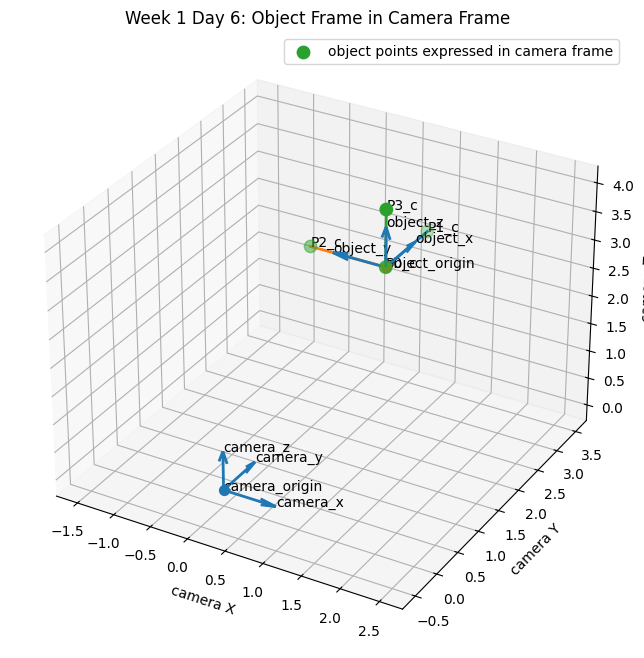

In [6]:

# ------------------------------------------------------------
# 6. 3D plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")
# 여기서 fig는 전체 그림판이고, ax는 실제로 좌표축과 점을 그리는 plot 영역이다.
# 111은 줄여 쓴 표현으로 1행1열1번째 subplot을 나타냄
# figure를 1행 1열로 나누고, 그중 첫 번째 칸에 plot을 만든다.

# camera frame 기준 좌표축 그리기
draw_frame(
    ax,
    origin=camera_origin,
    R=camera_R,
    name="camera",
    axis_length=0.7
)

# object frame을 camera frame 안에 그리기
draw_frame(
    ax,
    origin=object_origin_in_camera,
    R=object_R_in_camera,
    name="object",
    axis_length=0.7
)

# camera frame 기준으로 변환된 object points 그리기
ax.scatter(
    points_c[:, 0],
    points_c[:, 1],
    points_c[:, 2],
    s=80,
    label="object points expressed in camera frame"
)

# object point들을 선으로 연결해서 모양 확인
connections = [
    (0, 1),  # origin -> x point
    (0, 2),  # origin -> y point
    (0, 3),  # origin -> z point
]

for i, j in connections:
    ax.plot(
        [points_c[i, 0], points_c[j, 0]],
        [points_c[i, 1], points_c[j, 1]],
        [points_c[i, 2], points_c[j, 2]],
        linewidth=2
    )

# 각 점에 label 표시
for idx, p in enumerate(points_c):
    ax.text(p[0], p[1], p[2], f"P{idx}_c")

ax.set_title("Week 1 Day 6: Object Frame in Camera Frame")
ax.set_xlabel("camera X")
ax.set_ylabel("camera Y")
ax.set_zlabel("camera Z")
ax.legend()

set_axes_equal(ax)
plt.show()



In [7]:

# ------------------------------------------------------------
# 7. 변환 결과를 표처럼 출력
# ------------------------------------------------------------

print("\nFrame별 point 좌표 비교")
print("--------------------------------")

for i in range(len(points_o)):
    print(f"Point {i}")
    print(f"  object frame: {points_o[i]}")
    print(f"  camera frame: {points_c[i]}")
    print()




Frame별 point 좌표 비교
--------------------------------
Point 0
  object frame: [0. 0. 0.]
  camera frame: [1. 2. 3.]

Point 1
  object frame: [1. 0. 0.]
  camera frame: [1. 3. 3.]

Point 2
  object frame: [0. 1. 0.]
  camera frame: [0. 2. 3.]

Point 3
  object frame: [0. 0. 1.]
  camera frame: [1. 2. 4.]



In [13]:
# ============================================================
# Day 6: Interactive 3D Visualization
# 이전 셀에서 만든 변수/함수를 그대로 재사용한다.
# ============================================================
import plotly.graph_objects as go
import numpy as np


def add_frame_plotly(fig, origin, R, name, axis_length=0.7):
    """
    Plotly figure에 coordinate frame을 추가하는 함수

    origin: (3,)
    R: (3, 3)
       R의 column들이 frame의 x, y, z축 방향
    """

    axes = [
        ("x", R[:, 0]),
        ("y", R[:, 1]),
        ("z", R[:, 2]),
    ]

    for axis_name, axis_dir in axes:
        end = origin + axis_dir * axis_length

        # 축 선분
        fig.add_trace(go.Scatter3d(
            x=[origin[0], end[0]],
            y=[origin[1], end[1]],
            z=[origin[2], end[2]],
            mode="lines+markers+text",
            text=["", f"{name}_{axis_name}"],
            textposition="top center",
            name=f"{name}_{axis_name}",
            line=dict(width=6),
            marker=dict(size=4),
        ))

    # origin 표시
    fig.add_trace(go.Scatter3d(
        x=[origin[0]],
        y=[origin[1]],
        z=[origin[2]],
        mode="markers+text",
        text=[f"{name}_origin"],
        textposition="bottom center",
        name=f"{name}_origin",
        marker=dict(size=5),
    ))


fig = go.Figure()

# camera frame 추가
add_frame_plotly(
    fig,
    origin=camera_origin,
    R=camera_R,
    name="camera",
    axis_length=0.7
)

# object frame 추가
add_frame_plotly(
    fig,
    origin=object_origin_in_camera,
    R=object_R_in_camera,
    name="object",
    axis_length=0.7
)

# object points 추가
fig.add_trace(go.Scatter3d(
    x=points_c[:, 0],
    y=points_c[:, 1],
    z=points_c[:, 2],
    mode="markers+text",
    text=[f"P{i}_c" for i in range(len(points_c))],
    textposition="top center",
    name="object points in camera frame",
    marker=dict(size=6),
))

# object point 연결선
connections = [
    (0, 1),
    (0, 2),
    (0, 3),
]

for i, j in connections:
    fig.add_trace(go.Scatter3d(
        x=[points_c[i, 0], points_c[j, 0]],
        y=[points_c[i, 1], points_c[j, 1]],
        z=[points_c[i, 2], points_c[j, 2]],
        mode="lines",
        name=f"P{i}_c to P{j}_c",
        line=dict(width=5),
    ))

fig.update_layout(
    title="Interactive View: Object Frame in Camera Frame",
    scene=dict(
        xaxis_title="camera X",
        yaxis_title="camera Y",
        zaxis_title="camera Z",
        aspectmode="data",
    ),
    width=900,
    height=750,
)

fig.show()

## Day 7: 정리 및 README 업데이트
* 목표

    * 1주차 내용을 실험노트와 README에 정리합니다.

* 할 일
    * Experiment 001 정리
    * Week 1에서 배운 개념 정리
    * 헷갈린 점 정리
    * README에 Week 1 결과 추가
    * 다음 주 Camera Calibration으로 넘어갈 준비

# Week 1 Day 7: 정리 및 README 업데이트

## 오늘의 목표

Week 1에서 배운 좌표계 변환 개념을 정리한다.

핵심은 다음 문장을 설명할 수 있는 것이다.

6D pose estimation은 결국 물체 좌표계와 카메라 좌표계 사이의 R, t를 찾는 문제이다.

---

## Week 1에서 통과한 개념

### Day 1: 3D 점 하나 변환하기

object frame 기준 point `P_o`를 rotation matrix `R`과 translation vector `t`를 이용해 camera frame 기준 point `P_c`로 변환했다.

```text
P_c = R @ P_o + t

여기서 R은 방향을 바꾸고, t는 위치를 옮긴다.

Day 2: 여러 개의 3D 점 변환하기

여러 개의 3D point도 같은 R, t로 한 번에 변환할 수 있다.

row vector 형태에서는 다음과 같이 계산했다.

points_c = points_o @ R.T + t

points_o.shape = (N, 3)이며, 각 row가 하나의 3D point이다.

t는 broadcasting으로 모든 point에 더해진다.

6D pose에서는 물체 위의 모든 3D point가 같은 pose transform으로 함께 움직인다.

Day 3: Homogeneous Transformation Matrix

rotation matrix R과 translation vector t를 하나의 4x4 matrix T로 묶었다.

T[:3, :3] = R
T[:3, 3] = t

3D point P = [x, y, z]에 계산용 1을 붙여 homogeneous coordinate로 만들었다.

P_h = [x, y, z, 1]

그러면 다음 두 계산은 같은 결과를 낸다.

R @ P + t == (T @ P_h)[:3]

즉, T는 rotation과 translation을 한 번에 적용하기 위한 4x4 pose matrix이다.

Day 4: 좌표계 변환 방향 구분하기

T_co와 T_oc는 서로 반대 방향의 transform이다.

T_co: object frame -> camera frame
T_oc: camera frame -> object frame

두 transform은 inverse 관계이다.

T_oc = inverse(T_co)

따라서 다음이 성립한다.

P_c_h = T_co @ P_o_h
P_o_h = T_oc @ P_c_h

transform은 항상 입력 frame과 출력 frame이 정해져 있다.

방향을 헷갈리면 계산은 되더라도 의미가 틀릴 수 있다.

Day 5: Object Frame, Camera Frame, World Frame

같은 3D point도 어떤 frame에서 보느냐에 따라 좌표값이 달라진다.

P_c = T_co @ P_o

이 식은 실제 점이 바뀐다는 뜻이 아니다.

같은 3D point의 좌표 표현이 object frame 기준에서 camera frame 기준으로 바뀐다는 뜻이다.

여러 transform은 chain으로 연결할 수 있다.

T_co: object -> camera
T_wc: camera -> world

이면,

P_w = T_wc @ T_co @ P_o

이다.

행렬 곱에서는 오른쪽 변환이 먼저 적용된다.

Day 6: 3D 변환 시각화

Day 6에서는 object frame이 camera frame 안에서 어떻게 보이는지 시각화했다.

camera frame을 기준 frame으로 두고, object frame을 camera frame 안에 그렸다.

object origin in camera frame = t_co
object orientation in camera frame = R_co

points_o는 object frame 기준 point set이고, points_c는 같은 point set을 camera frame 기준으로 표현한 것이다.

3D 시각화는 pose의 rotation과 translation 오류를 빠르게 확인하는 디버깅 도구이다.


README에 붙일 섹션은 아래처럼 정리하면 된다.

```md
## Week 1: Coordinate Frames & 3D Transformation

Week 1에서는 6D pose estimation을 이해하기 위한 가장 기본적인 좌표계 변환을 학습했다.

6D pose estimation에서 물체의 pose는 보통 rotation `R`과 translation `t`로 표현된다.

```text
6D Pose = R + t

object frame 기준의 3D point P_o는 다음 식으로 camera frame 기준 point P_c로 변환된다.

P_c = R_co @ P_o + t_co

여기서 R_co는 object frame의 방향을 camera frame 기준으로 표현한 rotation matrix이고, t_co는 object frame origin의 camera frame 기준 위치를 나타내는 translation vector이다.

rotation과 translation은 4x4 homogeneous transformation matrix T_co로 묶을 수 있다.

P_c_h = T_co @ P_o_h

즉, T_co는 object frame의 point를 camera frame의 point로 변환하는 matrix이다.

Week 1에서 가장 중요하게 배운 점은 transform에는 항상 방향이 있다는 것이다.

T_co: object -> camera
T_oc: camera -> object

두 transform은 서로 inverse 관계이다.

T_oc = inverse(T_co)

또한 같은 3D point라도 어떤 coordinate frame에서 표현하느냐에 따라 좌표값이 달라진다.

6D pose estimation 관점에서 Week 1의 핵심 문장은 다음과 같다.

6D pose estimation은 object frame과 camera frame 사이의 R, t를 찾는 문제이다.

이후 PnP에서는 2D-3D correspondence를 이용해 T_co를 추정하고, ICP에서는 object model point cloud를 observed camera point cloud에 맞추는 transform을 추정한다.